In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

In [2]:
from transformers import BertTokenizer, BertModel

# load BERT tokenizer and model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

embeddings = model.embeddings.word_embeddings.weight.detach().numpy()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

In [3]:
# code to calculate the width of a letter
fig,ax = plt.subplots(figsize=(10,2))

# draw a text object
temp_text = ax.text(0,0,'n',fontsize=12,fontfamily='monospace')

# Get its bounding box in display coordinates
bbox = temp_text.get_window_extent(renderer=fig.canvas.get_renderer())

# convert from display to axis coordinates
inv = ax.transAxes.inverted()
bbox_axes = inv.transform([[bbox.x0,bbox.y0], [bbox.x1,bbox.y1]])
en_width = bbox_axes[1,0] - bbox_axes[0,0] # bbox is [(x0,y0),(x1,y1)]

plt.close(fig)
en_width

np.float64(0.012903225806451618)

# Word embedding norm/ magnitude heatmap

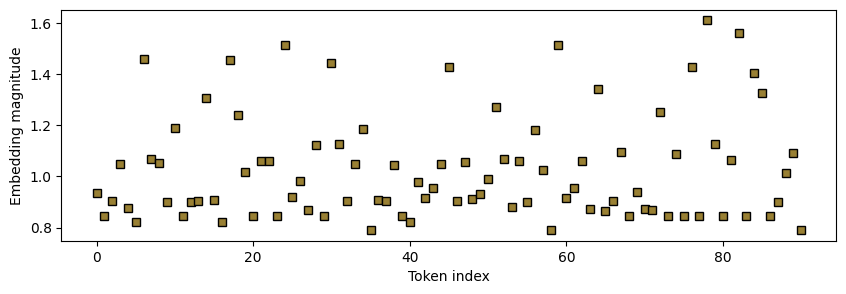

In [9]:
# tokenize text
# https://en.wikipedia.org/wiki/Tbilisi
text = "Because of its location at the crossroads between Europe and Asia, and its proximity to the lucrative Silk Road, throughout history, Tbilisi has been a point of contention among various global powers. To this day, the city's location ensures its position as an important transit route for energy and trade projects. Tbilisi's history is reflected in its architecture, which is a mix of medieval, neoclassical, Beaux Arts, Art Nouveau, Stalinist, and Modern structures."
tokens = tokenizer.encode(text)[1:-1]

# get all magnitudes
norms = np.zeros(len(tokens))
for i,token in enumerate(tokens):
  norms[i] = np.linalg.norm(embeddings[token])

# plot

plt.figure(figsize=(10,3))
plt.plot(norms,'ks',markerfacecolor=[.6,.5,.2])
plt.gca().set(xlabel='Token index',ylabel='Embedding magnitude')
plt.show()

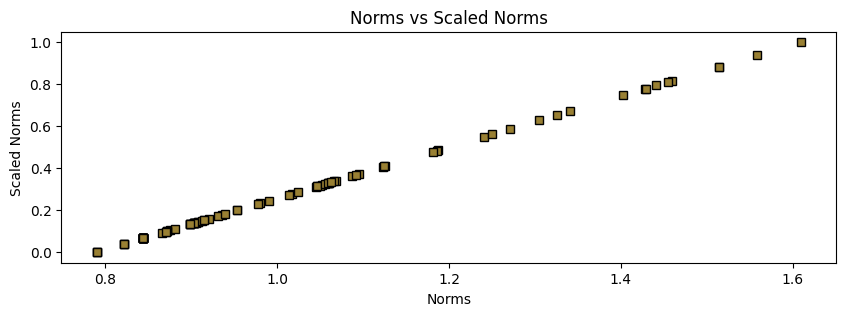

In [12]:
# Scale the norms
scaled_norms = (norms - np.min(norms)) / (np.max(norms) - np.min(norms))

plt.figure(figsize=(10,3))
plt.plot(norms, scaled_norms,'ks',markerfacecolor=[.6,.5,.2])
plt.gca().set(xlabel='Norms',ylabel='Scaled Norms', title='Norms vs Scaled Norms')
plt.show()

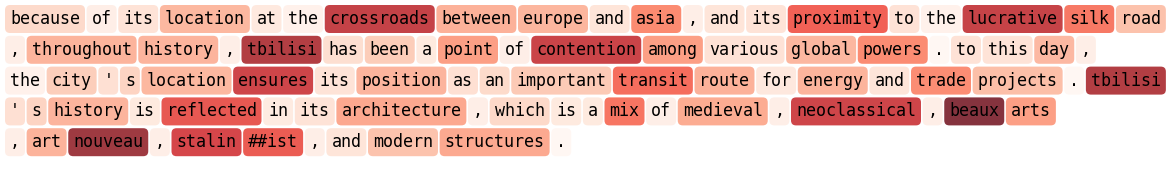

In [13]:
tokCount = 0

x_pos = 0  # starting x position (in axis coordinates)
y_pos = 1  # vertical center

fig, ax = plt.subplots(figsize=(10,2))
ax.axis('off')

for toki in range(len(tokens)):

  # text of this token
  toktext = tokenizer.decode([tokens[toki]])

  # width of the token
  token_width = en_width*len(toktext)

  # text object with background color matching the "activation"
  ax.text(x_pos+token_width/2, y_pos, toktext, fontsize=12, ha='center', va='center',fontfamily='monospace',
          bbox = dict(boxstyle='round,pad=.3', facecolor=mpl.cm.Reds(scaled_norms[toki]), edgecolor='none', alpha=.8))

  # update the token counter and x_pos
  tokCount += 1
  x_pos += token_width + .015 # plus a small gap

  # end of the line; reset coordinates and counter
  if tokCount>=20:
    y_pos -= .2
    x_pos = 0
    tokCount = 0

plt.show()

# Cosine Similarity Heatmap

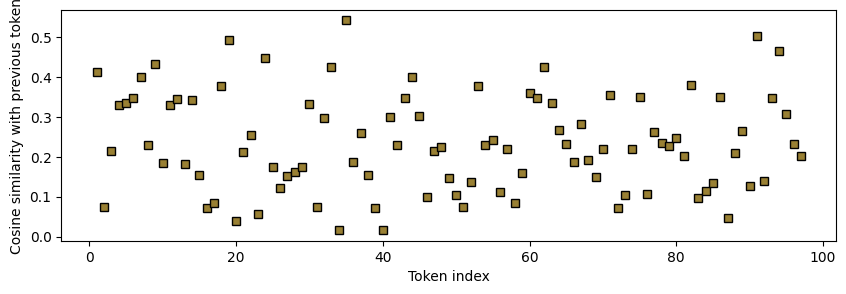

In [14]:
# tokenize text
# https://en.wikipedia.org/wiki/Algae_fuel
text = "Algae fuel, algal biofuel, or algal oil is an alternative to liquid fossil fuels that use algae as the source of energy-rich oils. Also, algae fuels are an alternative to commonly known biofuel sources, such as corn and sugarcane. When made from seaweed (macroalgae) it can be known as seaweed fuel or seaweed oil.  These fuels have no practical significance but remain an aspirational target in the biofuels research area."
tokens = tokenizer.encode(text)[1:-1]

# get all similiarities
cossims = np.full(len(tokens),np.nan)

for i in range(1,len(tokens)):

  # previous token embedding
  v1 = embeddings[tokens[i-1],:].squeeze()
  v1norm = sum(v1**2)

  # current token embedding
  v2 = embeddings[tokens[i],:]
  v2norm = sum(v2**2)
  cossims[i] = abs( sum(v1*v2) / np.sqrt( v1norm*v2norm ) )

plt.figure(figsize=(10,3))
plt.plot(cossims,'ks',markerfacecolor=[.6,.5,.2])
plt.gca().set(xlabel='Token index',ylabel='Cosine similarity with previous token')
plt.show()

In [15]:
# Do we need to scale after the loop?
# Couldn't we incorporate this into the previous for-loop?
scaled_cs = (cossims - np.nanmin(cossims)) / (np.nanmax(cossims)-np.nanmin(cossims))
print(scaled_cs)
scaled_cs[0] = 0

[           nan 7.54657415e-01 1.12665603e-01 3.77753251e-01
 5.95652282e-01 6.05471414e-01 6.29801317e-01 7.29907549e-01
 4.07111353e-01 7.89986329e-01 3.19295151e-01 5.95652282e-01
 6.22958289e-01 3.13411503e-01 6.21777901e-01 2.61768299e-01
 1.06515004e-01 1.28016089e-01 6.85400673e-01 9.03477963e-01
 4.35675555e-02 3.71065102e-01 4.53199213e-01 7.84735299e-02
 8.19025344e-01 3.02143421e-01 2.01435332e-01 2.58586482e-01
 2.75475982e-01 3.02488009e-01 5.99675440e-01 1.12950352e-01
 5.35610426e-01 7.76157440e-01 6.95513587e-04 1.00000000e+00
 3.23865613e-01 4.62182319e-01 2.61768299e-01 1.06515004e-01
 0.00000000e+00 5.39179919e-01 4.07938218e-01 6.29801317e-01
 7.29907549e-01 5.43984310e-01 1.57857825e-01 3.75447523e-01
 3.96711385e-01 2.48457395e-01 1.68078811e-01 1.11958656e-01
 2.29703391e-01 6.88318875e-01 4.03506208e-01 4.30938029e-01
 1.79683552e-01 3.88575925e-01 1.31726763e-01 2.70773712e-01
 6.51966883e-01 6.31735400e-01 7.75897388e-01 6.06537580e-01
 4.78911598e-01 4.114206

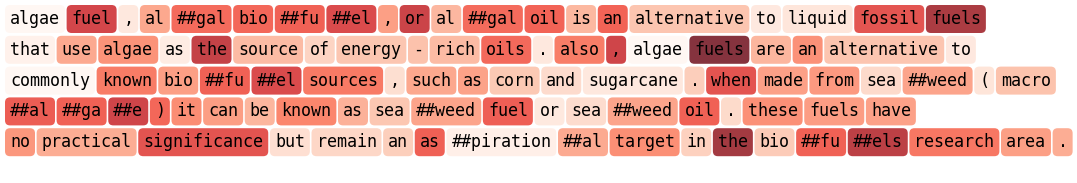

In [16]:
tokCount = 0

x_pos = 0  # starting x position (in axis coordinates)
y_pos = 1  # vertical center

fig, ax = plt.subplots(figsize=(10,2))
ax.axis('off')

for toki in range(len(tokens)):

  # text of this token
  toktext = tokenizer.decode([tokens[toki]])

  # width of the token
  token_width = en_width*len(toktext)

  # text object with background color matching the "activation"
  ax.text(x_pos+token_width/2, y_pos, toktext, fontsize=12, ha='center', va='center',fontfamily='monospace',
          bbox = dict(boxstyle='round,pad=.3', facecolor=mpl.cm.Reds(scaled_cs[toki]), edgecolor='none', alpha=.8))

  # update the token counter and x_pos
  tokCount += 1
  x_pos += token_width + .015 # plus a small gap

  # end of the line; reset coordinates and counter
  if tokCount>=20:
    y_pos -= .2
    x_pos = 0
    tokCount = 0

plt.show()

# Heatmap of Cosine Similarity with a seed word

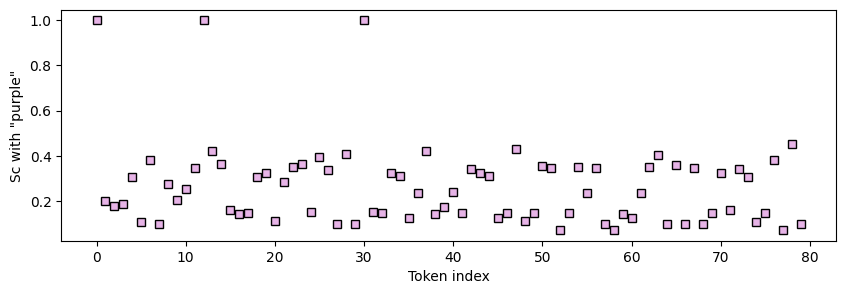

In [17]:
# tokenize text
# https://en.wikipedia.org/wiki/Purple
text = "Purple has long been associated with royalty, originally because Tyrian purple dye—made from the secretions of sea snails—was extremely expensive in antiquity. Purple was the color worn by Roman magistrates; it became the imperial color worn by the rulers of the Byzantine Empire and the Holy Roman Empire, and later by Roman Catholic bishops. Similarly in Japan, the color is traditionally associated with the emperor and aristocracy."
tokens = tokenizer.encode(text)[1:-1]

# the "seed" token embedding
seedtok = tokenizer.encode('purple')[1:-1]
seedvect = embeddings[seedtok,:].squeeze()
seednorm = sum(seedvect**2)

# stored value is abs(cosine similarity) to seed
cossims = np.zeros(len(tokens))
for i,token in enumerate(tokens):
  targvect = embeddings[token,:]
  targnorm = sum(targvect**2)
  cossims[i] = abs( sum(seedvect*targvect) / np.sqrt( seednorm*targnorm ) )

plt.figure(figsize=(10,3))
plt.plot(cossims,'ks',markerfacecolor=[.9,.7,.9])
plt.gca().set(xlabel='Token index',ylabel='Sc with "purple"')
plt.show()

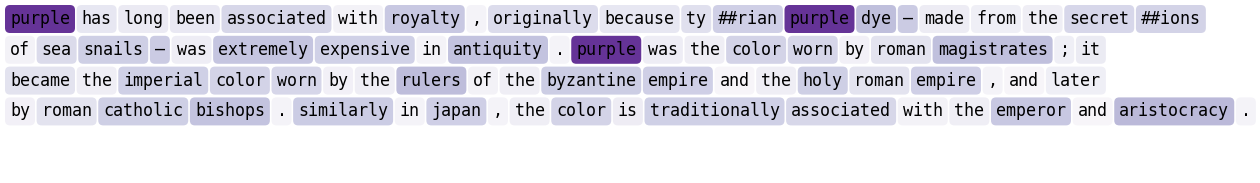

In [18]:
# min-max scale
scaled_cs = (cossims - np.nanmin(cossims))/(np.nanmax(cossims)-np.nanmin(cossims))


tokCount = 0

x_pos = 0  # starting x position (in axis coordinates)
y_pos = 1  # vertical center

fig, ax = plt.subplots(figsize=(10,2))
ax.axis('off')

for toki in range(len(tokens)):

  # text of this token
  toktext = tokenizer.decode([tokens[toki]])

  # width of the token
  token_width = en_width*len(toktext)

  # text object with background color matching the "activation"
  ax.text(x_pos+token_width/2, y_pos, toktext, fontsize=12, ha='center', va='center',fontfamily='monospace',
          bbox = dict(boxstyle='round,pad=.3', facecolor=mpl.cm.Purples(cossims[toki]), edgecolor='none', alpha=.8))

  # update the token counter and x_pos
  tokCount += 1
  x_pos += token_width + .015 # plus a small gap

  # end of the line; reset coordinates and counter
  if tokCount>=20:
    y_pos -= .2
    x_pos = 0
    tokCount = 0

plt.show()

# Interpretation of randomised embeddings

In [24]:
# get permuted indices
randindices = np.random.permutation(np.prod(embeddings.shape))

# randomize the vectorized matrix
embeddings_flat = embeddings.flatten()[randindices]

# reshape back to 2D
embeddings = embeddings_flat.reshape(embeddings.shape)

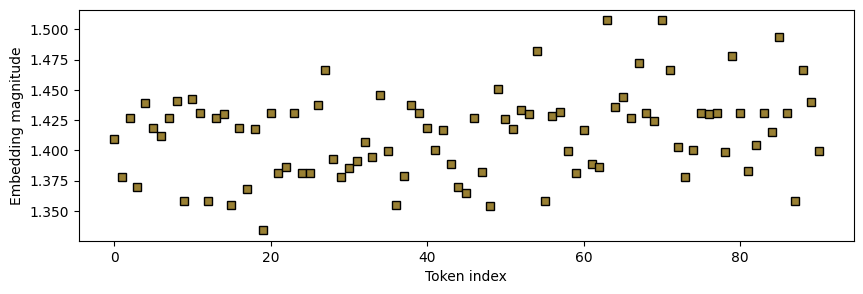

In [27]:
# tokenize text
# https://en.wikipedia.org/wiki/Tbilisi
text = "Because of its location at the crossroads between Europe and Asia, and its proximity to the lucrative Silk Road, throughout history, Tbilisi has been a point of contention among various global powers. To this day, the city's location ensures its position as an important transit route for energy and trade projects. Tbilisi's history is reflected in its architecture, which is a mix of medieval, neoclassical, Beaux Arts, Art Nouveau, Stalinist, and Modern structures."
tokens = tokenizer.encode(text)[1:-1]

# get all magnitudes
norms = np.zeros(len(tokens))
for i,token in enumerate(tokens):
  norms[i] = np.linalg.norm(embeddings[token])

# plot

plt.figure(figsize=(10,3))
plt.plot(norms,'ks',markerfacecolor=[.6,.5,.2])
plt.gca().set(xlabel='Token index',ylabel='Embedding magnitude')
plt.show()

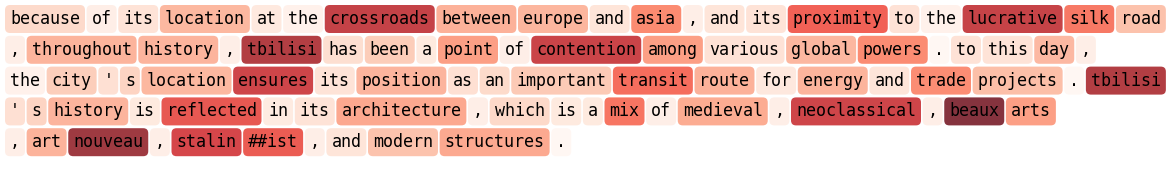

In [29]:
tokCount = 0

x_pos = 0  # starting x position (in axis coordinates)
y_pos = 1  # vertical center

fig, ax = plt.subplots(figsize=(10,2))
ax.axis('off')

for toki in range(len(tokens)):

  # text of this token
  toktext = tokenizer.decode([tokens[toki]])

  # width of the token
  token_width = en_width*len(toktext)

  # text object with background color matching the "activation"
  ax.text(x_pos+token_width/2, y_pos, toktext, fontsize=12, ha='center', va='center',fontfamily='monospace',
          bbox = dict(boxstyle='round,pad=.3', facecolor=mpl.cm.Reds(scaled_norms[toki]), edgecolor='none', alpha=.8))

  # update the token counter and x_pos
  tokCount += 1
  x_pos += token_width + .015 # plus a small gap

  # end of the line; reset coordinates and counter
  if tokCount>=20:
    y_pos -= .2
    x_pos = 0
    tokCount = 0

plt.show()

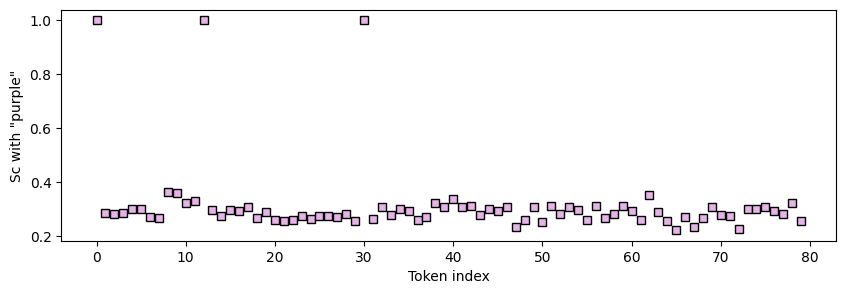

In [30]:
# tokenize text
# https://en.wikipedia.org/wiki/Purple
text = "Purple has long been associated with royalty, originally because Tyrian purple dye—made from the secretions of sea snails—was extremely expensive in antiquity. Purple was the color worn by Roman magistrates; it became the imperial color worn by the rulers of the Byzantine Empire and the Holy Roman Empire, and later by Roman Catholic bishops. Similarly in Japan, the color is traditionally associated with the emperor and aristocracy."
tokens = tokenizer.encode(text)[1:-1]

# the "seed" token embedding
seedtok = tokenizer.encode('purple')[1:-1]
seedvect = embeddings[seedtok,:].squeeze()
seednorm = sum(seedvect**2)

# stored value is abs(cosine similarity) to seed
cossims = np.zeros(len(tokens))
for i,token in enumerate(tokens):
  targvect = embeddings[token,:]
  targnorm = sum(targvect**2)
  cossims[i] = abs( sum(seedvect*targvect) / np.sqrt( seednorm*targnorm ) )

plt.figure(figsize=(10,3))
plt.plot(cossims,'ks',markerfacecolor=[.9,.7,.9])
plt.gca().set(xlabel='Token index',ylabel='Sc with "purple"')
plt.show()

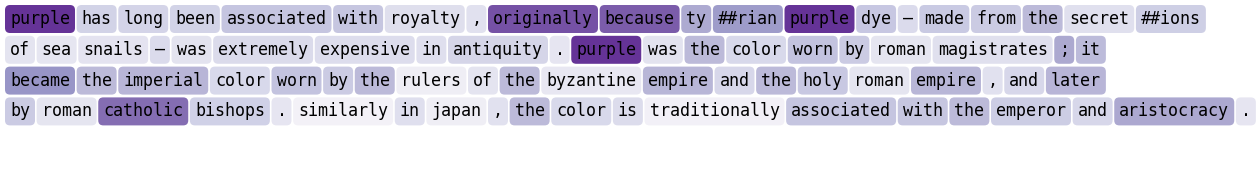

In [39]:
# min-max scale
scaled_cs = (cossims - np.nanmin(cossims))/(np.nanmax(cossims)-np.nanmin(cossims))


tokCount = 0

x_pos = 0  # starting x position (in axis coordinates)
y_pos = 1  # vertical center

fig, ax = plt.subplots(figsize=(10,2))
ax.axis('off')

for toki in range(len(tokens)):

  # text of this token
  toktext = tokenizer.decode([tokens[toki]])

  # width of the token
  token_width = en_width*len(toktext)

  # text object with background color matching the "activation"
  ax.text(x_pos+token_width/2, y_pos, toktext, fontsize=12, ha='center', va='center',fontfamily='monospace',
          bbox = dict(boxstyle='round,pad=.3', facecolor=mpl.cm.Purples(cossims[toki]**4*50), edgecolor='none', alpha=.8))

  # update the token counter and x_pos
  tokCount += 1
  x_pos += token_width + .015 # plus a small gap

  # end of the line; reset coordinates and counter
  if tokCount>=20:
    y_pos -= .2
    x_pos = 0
    tokCount = 0

plt.show()